# Step 1: Import Required Libraries
In this step, we import all the libraries required for data manipulation, visualization, preprocessing, clustering, classification, and model evaluation.

In [321]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

from xgboost import XGBClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

# Step 2: Load the Dataset

The dataset contains socio-economic and health indicators for 167 countries. These features will be used to identify similar groups using clustering techniques and later build classification models for customer intelligence.

In [322]:
# Load the dataset

df = pd.read_csv("Country-data.csv")

# Display first 5 rows
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Step 3: Dataset Inspection

Before preprocessing, it is important to inspect the dataset to understand its dimensions, data types, missing values, duplicate records, and statistical summary. This helps identify any issues that may affect model performance.

In [323]:
# Display first five rows

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [324]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 167
Number of Columns : 10


In [325]:
print(df.columns.tolist())

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [326]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [327]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [328]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [329]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [330]:
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

## Observations

- The dataset contains **167 rows** and **10 columns**.
- There is **1 categorical feature (`country`)** and **9 numerical features**.
- No missing values are present.
- No duplicate records are found.
- The dataset is clean and ready for preprocessing and exploratory data analysis.

# Step 4: Data Cleaning & Preprocessing

Before applying machine learning algorithms, the dataset is cleaned and standardized to ensure consistency. This includes:

- Standardizing column names
- Removing duplicate records
- Converting columns to appropriate data types
- Handling missing values (if any)

In [331]:
# Create a copy of the original dataset

df = df.copy()

In [332]:
# Convert column names to lowercase and remove extra spaces

df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [333]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (167, 10)


In [334]:
# Convert all columns except 'country' to numeric

numeric_cols = df.columns.drop("country")

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [335]:
# Fill missing values with median

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [336]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Observations

- Column names have been standardized.
- No duplicate records were found.
- All numerical features have appropriate data types.
- No missing values remain in the dataset.
- The dataset is now clean and ready for exploratory data analysis.

# Step 5: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the relationships, distributions, and characteristics of the dataset before applying machine learning algorithms.

The following analyses are performed:

- Correlation Heatmap
- Feature Distributions
- Boxplots for Outlier Detection

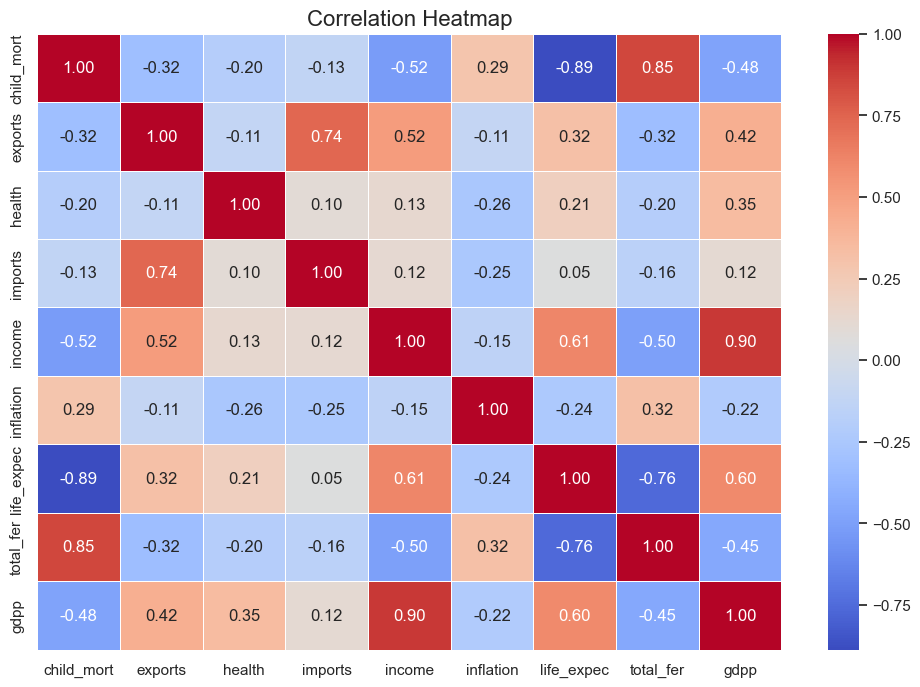

In [337]:
# Correlation Matrix

plt.figure(figsize=(12,8))

corr_matrix = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

### Observation

The correlation heatmap shows the relationships among numerical variables.

Some features such as **income**, **gdpp**, and **life expectancy** exhibit strong positive correlations, while **child mortality** tends to have a strong negative correlation with these development-related indicators.

These relationships suggest that the dataset contains meaningful patterns suitable for clustering and classification.

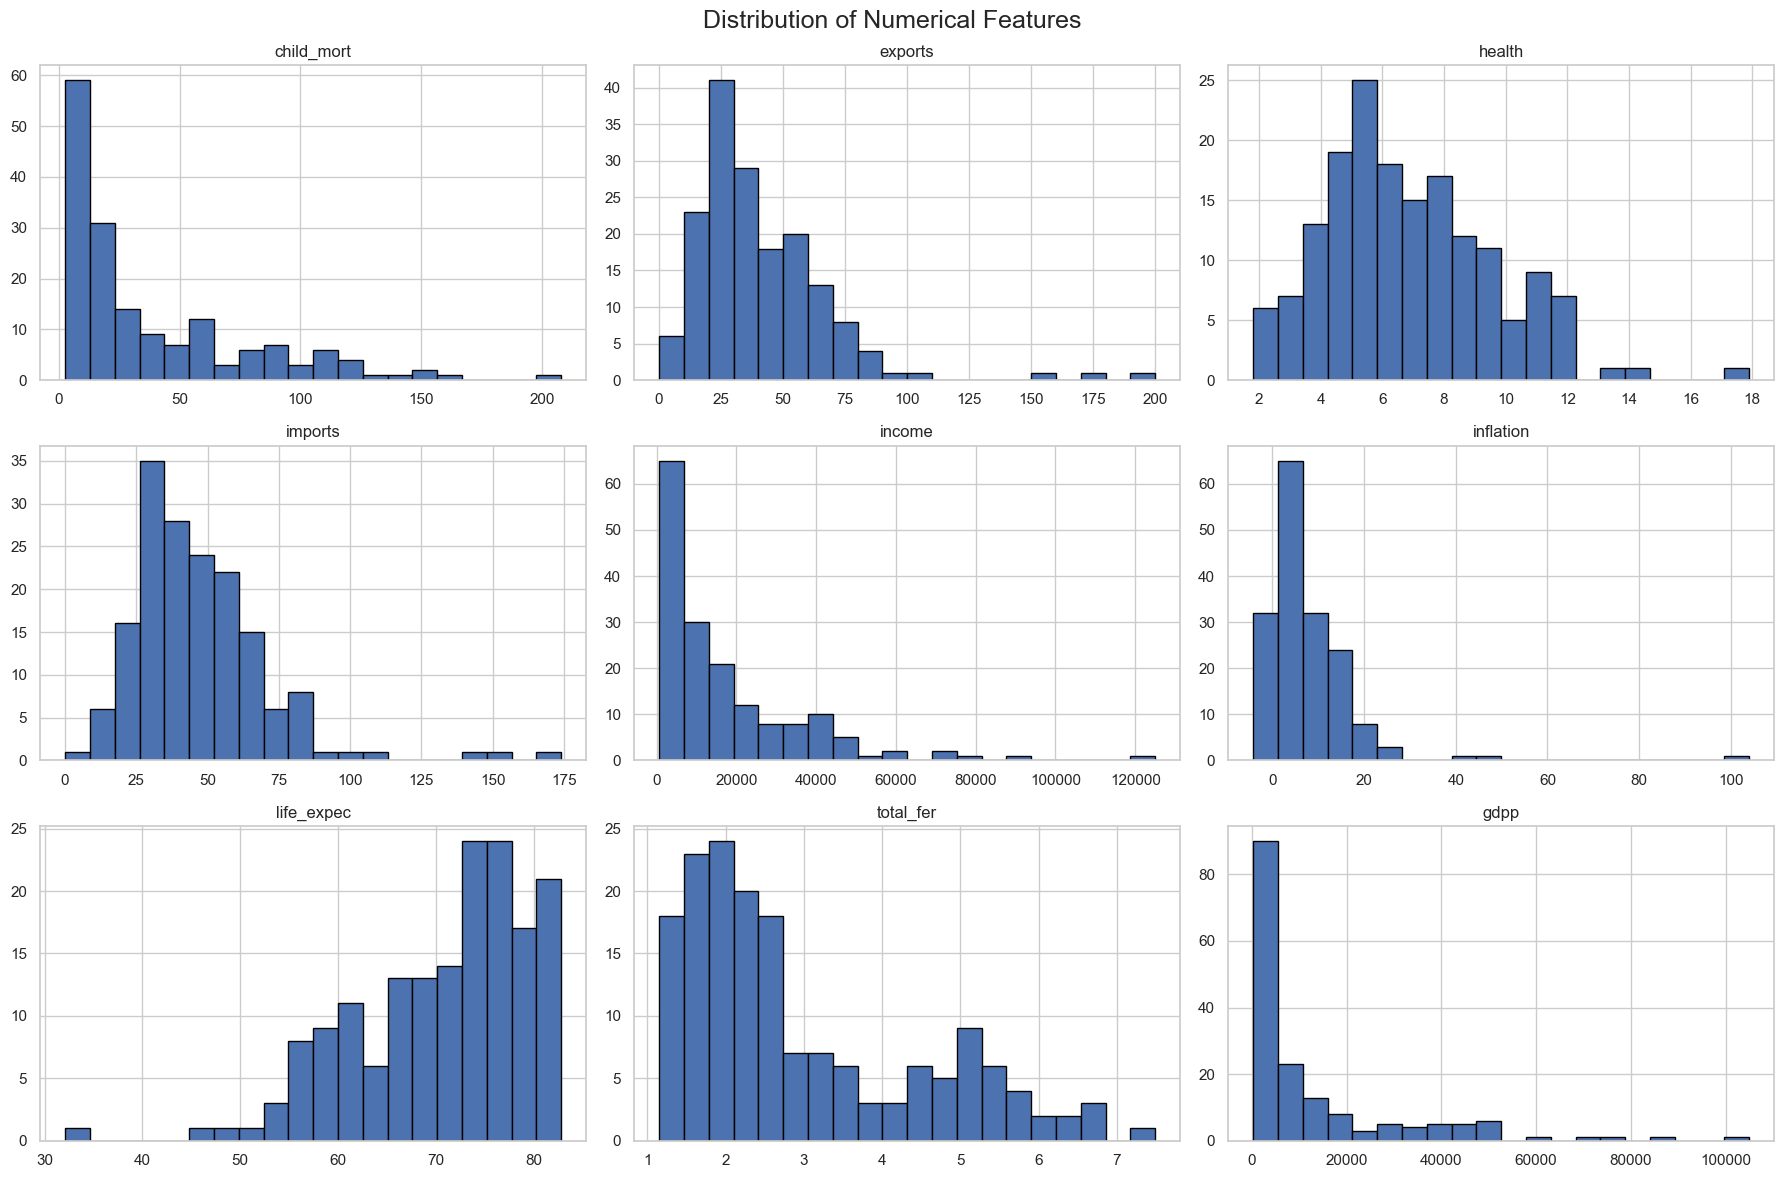

In [338]:
# Distribution of all numerical features

df[numeric_cols].hist(
    figsize=(18,12),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()

### Observation

The feature distributions indicate that several variables, including **income** and **GDP per capita**, are right-skewed, while others appear more evenly distributed.

These differences in scale further justify the use of feature scaling before clustering.

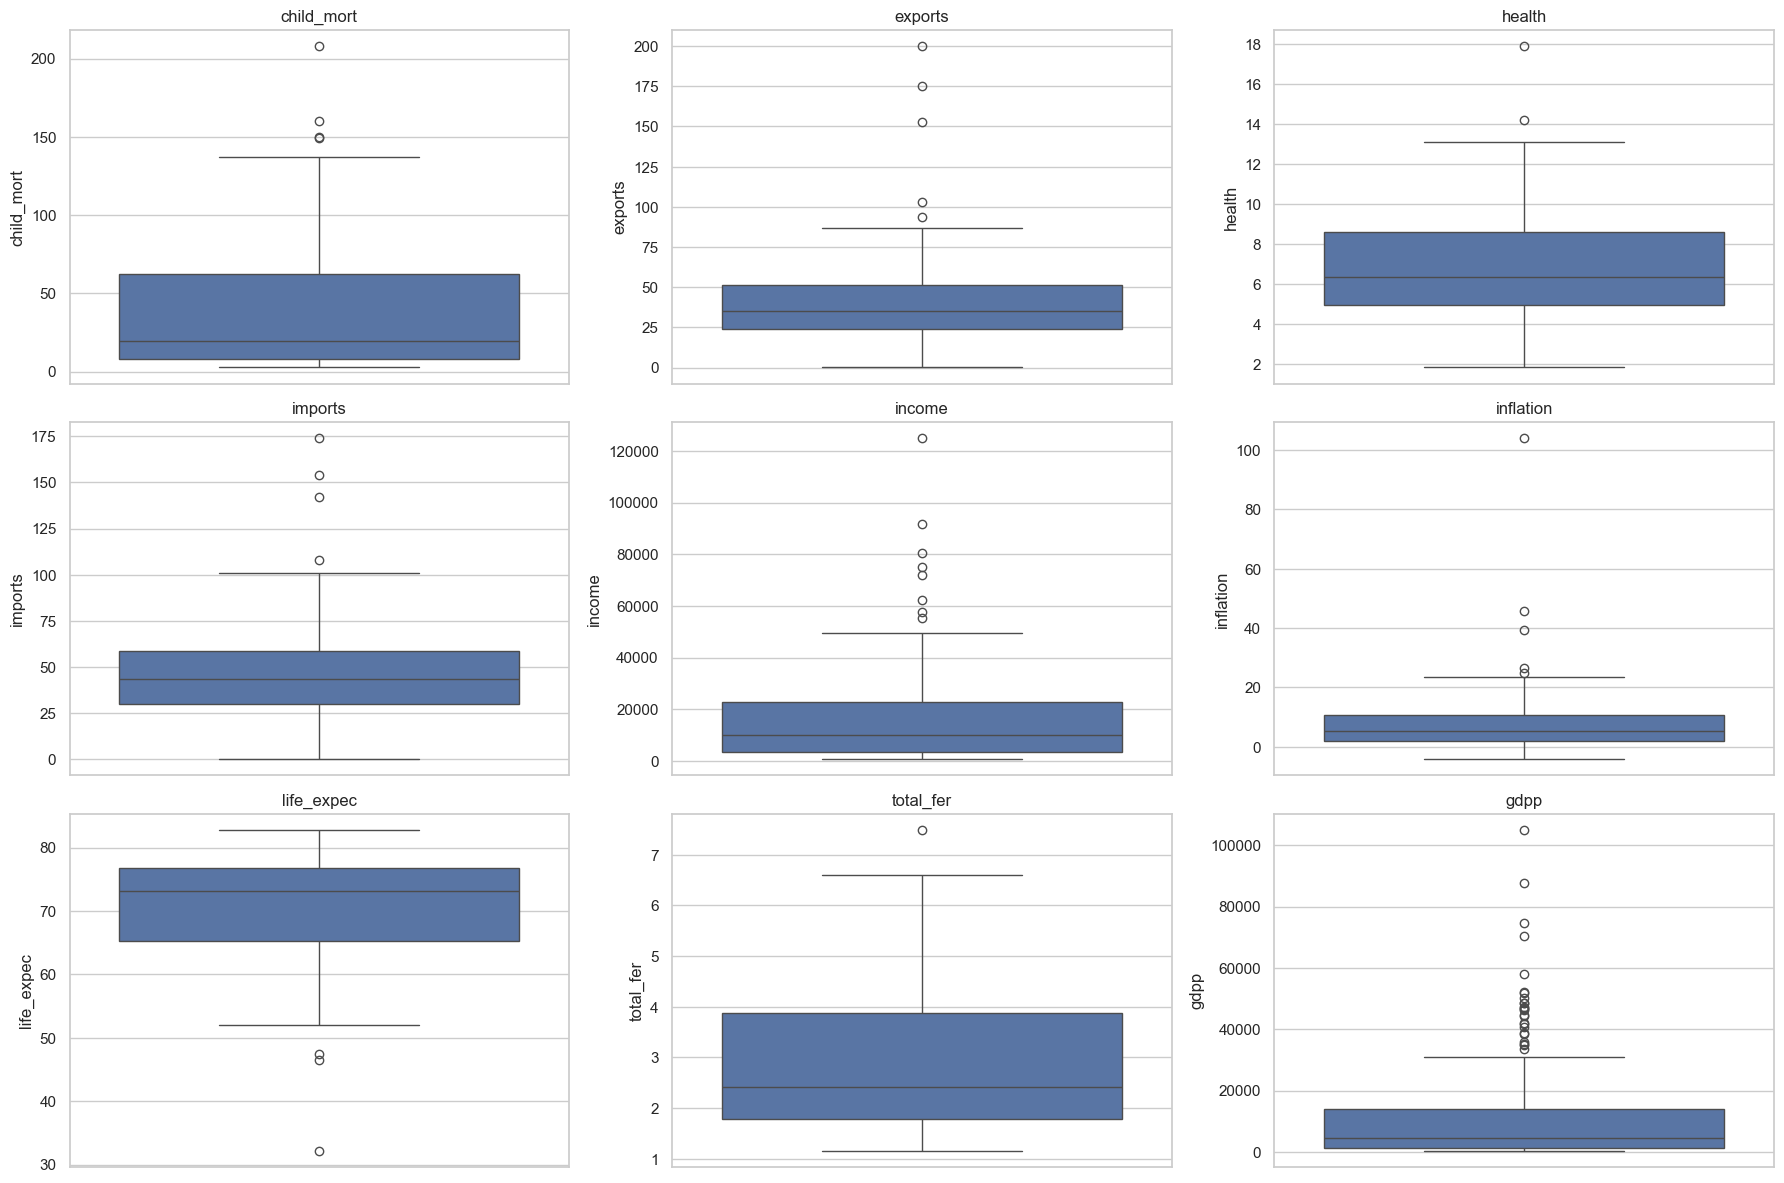

In [339]:
# Boxplots to detect outliers

plt.figure(figsize=(18,12))

for i, col in enumerate(numeric_cols, 1):

    plt.subplot(3,3,i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

### Observation

Several numerical features contain outliers, particularly **GDP per capita**, **income**, and **inflation**.

These outliers represent countries with exceptionally high or low economic indicators and are retained because they provide meaningful information rather than measurement errors.

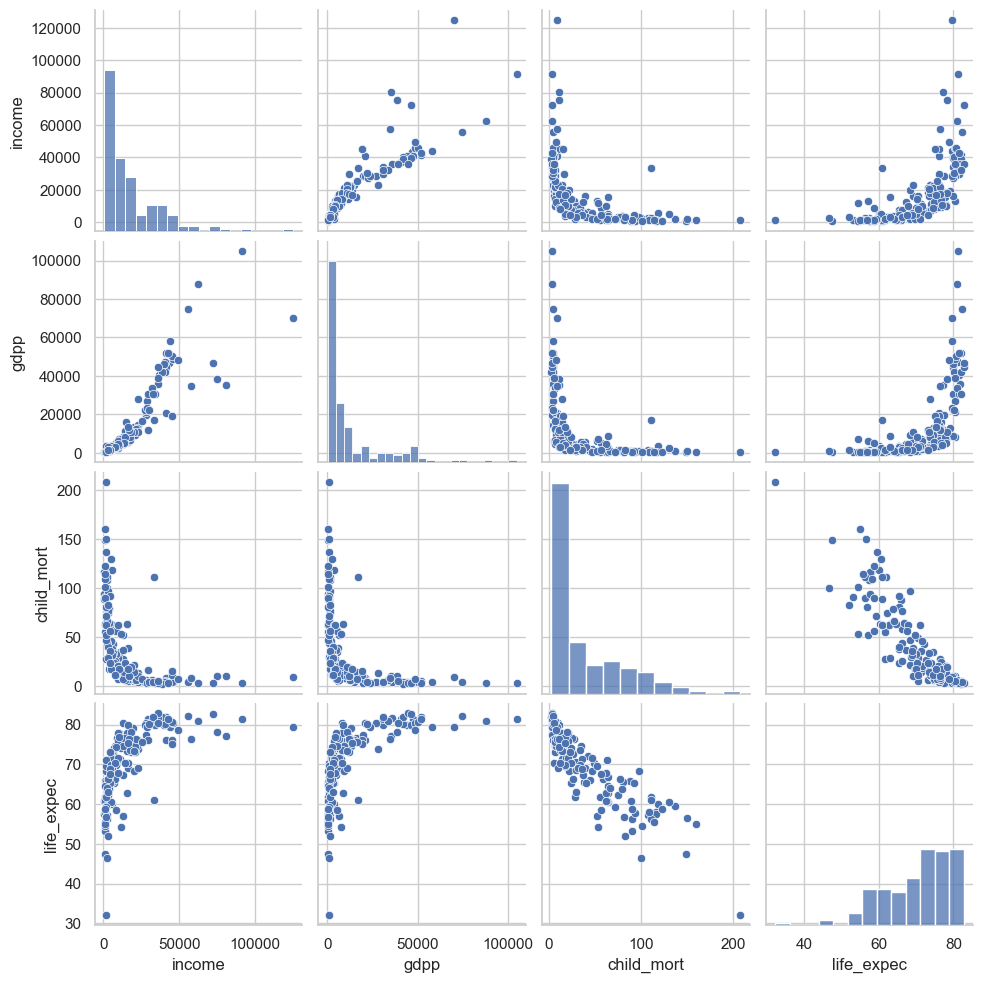

In [340]:
# Pairplot of selected important features

selected_features = [
    "income",
    "gdpp",
    "child_mort",
    "life_expec"
]

sns.pairplot(
    df[selected_features],
    diag_kind="hist"
)

plt.show()

### Observation

The pairplot reveals noticeable relationships among the selected variables.

Countries with higher income generally have higher GDP per capita and life expectancy, while child mortality decreases as economic conditions improve.

In [341]:
# Summary Statistics

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


### Key Findings

- The dataset contains a wide range of economic and health indicators.
- Income and GDP exhibit significant variability across countries.
- Child mortality and life expectancy display an inverse relationship.
- The data is suitable for clustering due to the presence of distinct patterns among countries.

# Step 6: Feature Scaling

Machine learning algorithms such as K-Means, DBSCAN, and PCA are sensitive to the scale of the features.

To ensure that each feature contributes equally to the analysis, the numerical features are standardized using StandardScaler.

In [342]:
# Remove the country column

features = df.drop(columns=["country"])

features.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [343]:
# Standardize the features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

In [344]:
print("Scaled Dataset Shape:", X_scaled.shape)

Scaled Dataset Shape: (167, 9)


In [345]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=features.columns
)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [346]:
scaled_df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04


## Observation

The numerical features have been standardized successfully.

Each feature now has a mean close to **0** and a standard deviation close to **1**, ensuring that all variables contribute equally during clustering and dimensionality reduction.

# Step 7: Finding the Optimal Number of Clusters (Elbow Method)

Before training the K-Means model, it is important to determine the optimal number of clusters.

The Elbow Method is used to compare different values of **K** and identify the point where adding more clusters provides only a small improvement in clustering performance.

In [347]:
# Calculate inertia for different values of K

inertia = []

K = range(2, 11)

for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

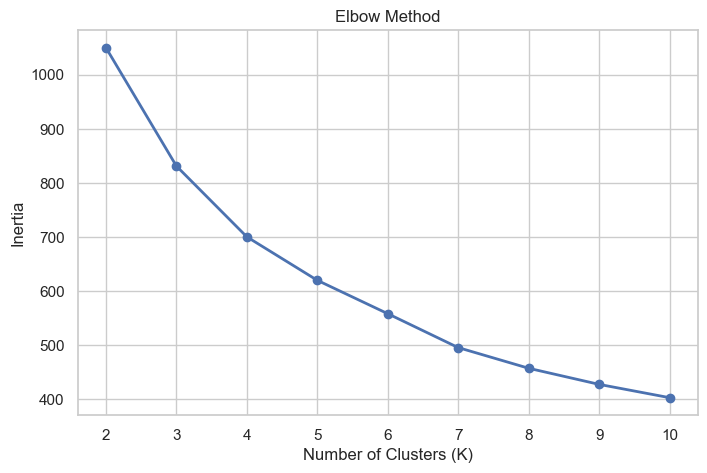

In [348]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.xticks(K)

plt.grid(True)

plt.show()

## Observation

The Elbow Method indicates that the optimal number of clusters is **K = 3**, as the reduction in inertia begins to slow significantly after this point.

Therefore, **K = 3** is selected for training the K-Means clustering model.

# Step 8: K-Means Clustering

K-Means clustering is applied using the optimal number of clusters determined by the Elbow Method.

The model groups countries with similar socio-economic characteristics into distinct clusters. The quality of clustering is evaluated using the Silhouette Score.

In [349]:
# Train the K-Means model

best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [350]:
# Number of countries in each cluster

df["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64

In [351]:
# Evaluate clustering performance

score = silhouette_score(X_scaled, df["kmeans_cluster"])

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2833


## Observation

The K-Means algorithm successfully segmented the countries into **three distinct clusters**.

The Silhouette Score indicates the quality of clustering by measuring how similar each country is to its own cluster compared to other clusters. A positive score suggests that the clusters are reasonably well separated.

In [352]:
# Display country names with assigned clusters

df[["country", "kmeans_cluster"]].head(20)

,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2
5,Argentina,2
6,Armenia,2
7,Australia,0
8,Austria,0
9,Azerbaijan,2


# Step 9: DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm.

Unlike K-Means, DBSCAN does not require specifying the number of clusters beforehand. It groups closely packed data points together and identifies points in low-density regions as noise (outliers).

In [353]:
# Train DBSCAN model

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

In [354]:
# Number of countries in each DBSCAN cluster

df["dbscan_cluster"].value_counts().sort_index()

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

In [355]:
df[["country", "kmeans_cluster", "dbscan_cluster"]].head(20)

,country,kmeans_cluster,dbscan_cluster
0,Afghanistan,1,0
1,Albania,2,0
2,Algeria,2,0
3,Angola,1,-1
4,Antigua and Barbuda,2,0
5,Argentina,2,0
6,Armenia,2,0
7,Australia,0,0
8,Austria,0,0
9,Azerbaijan,2,0


In [356]:
noise_points = (df["dbscan_cluster"] == -1).sum()

print("Number of Noise Points:", noise_points)

Number of Noise Points: 30


## Observation

DBSCAN identified clusters based on the density of the data points rather than requiring a predefined number of clusters.

The algorithm detected **30 countries as noise points (cluster -1)**. These countries have socio-economic characteristics that differ significantly from the main clusters, making them potential outliers.

Compared to K-Means, DBSCAN is more effective at identifying outliers but may classify a larger number of observations as noise depending on the chosen parameters.

# Step 10: Visualizing Clusters using PCA

The dataset contains nine numerical features, making it difficult to visualize the clusters directly.

Principal Component Analysis (PCA) is used to reduce the dimensionality of the data from **9 dimensions to 2 dimensions**, allowing the clusters formed by K-Means to be visualized on a two-dimensional plot.

In [357]:
# Apply PCA to reduce dimensions

pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

In [358]:
# Create a DataFrame for visualization

pca_df = pd.DataFrame({
    "PCA1": X_pca[:,0],
    "PCA2": X_pca[:,1],
    "Cluster": df["kmeans_cluster"]
})

pca_df.head()

,PCA1,PCA2,Cluster
0,-2.913025,0.095621,1
1,0.429911,-0.588156,2
2,-0.285225,-0.455174,2
3,-2.932423,1.695555,1
4,1.033576,0.136659,2


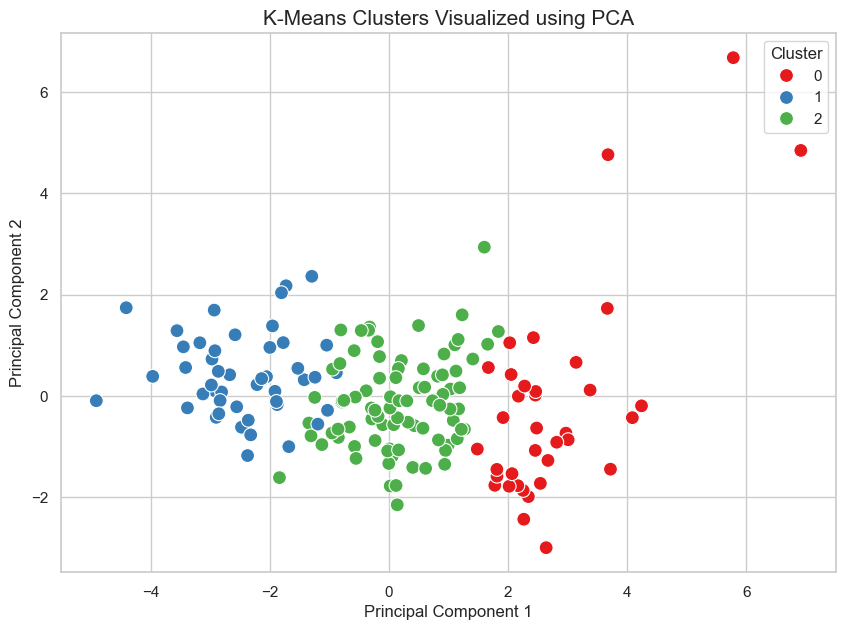

In [359]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title("K-Means Clusters Visualized using PCA", fontsize=15)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.grid(True)

plt.show()

In [360]:
# Explained variance ratio

print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

print()

print("Total Variance Explained:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.4595174  0.17181626]

Total Variance Explained: 0.6313336543771411


## Observation

PCA successfully reduced the dataset from **9 dimensions to 2 principal components**, making it easier to visualize the clusters.

The scatter plot shows that the countries are grouped into **three distinct clusters**, indicating that K-Means has successfully identified meaningful patterns in the socio-economic data.

The first two principal components capture a significant portion of the total variance, making the visualization representative of the original dataset.

# Step 11: Cluster Profiling

After clustering the countries, the next step is to analyze the characteristics of each cluster.

Cluster profiling calculates the average values of all numerical features for each cluster, helping identify the socio-economic characteristics of each group.

In [361]:
# Calculate average values of each cluster

cluster_profile = df.groupby("kmeans_cluster")[numeric_cols].mean().round(2)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


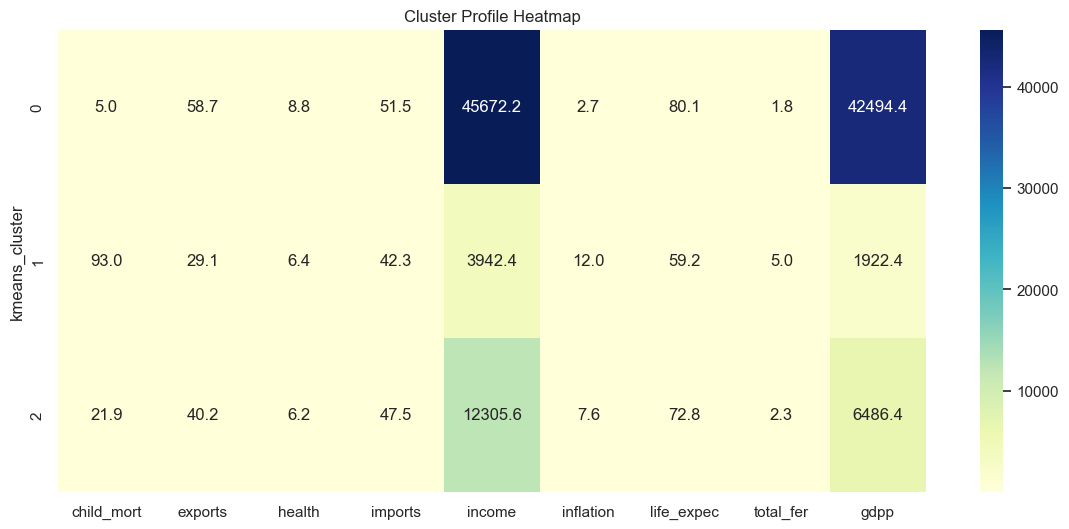

In [362]:
plt.figure(figsize=(14,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Cluster Profile Heatmap")

plt.show()

In [363]:
df["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64

In [364]:
for cluster in sorted(df["kmeans_cluster"].unique()):
    print("=" * 60)
    print(f"Cluster {cluster}")
    print("=" * 60)
    print(df[df["kmeans_cluster"] == cluster]["country"].tolist())
    print()

Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kuwait', 'Luxembourg', 'Malta', 'Netherlands', 'New Zealand', 'Norway', 'Portugal', 'Qatar', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'United Arab Emirates', 'United Kingdom', 'United States']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Tog

## Observation

The cluster profile reveals distinct socio-economic groups among the countries.

- One cluster represents **high-income, highly developed countries** with high GDP per capita and long life expectancy.
- Another cluster represents **developing countries** with moderate economic indicators.
- The remaining cluster consists of **underdeveloped countries** characterized by high child mortality, low income, and lower life expectancy.

These profiles provide meaningful insights for policy-making, investment strategies, and international aid allocation.

In [365]:
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## Business Insights

### Cluster 0 – Developed Countries
- Highest average income and GDP per capita.
- Lowest child mortality rate.
- Highest life expectancy.
- Represents economically advanced and well-developed countries.

### Cluster 1 – Underdeveloped Countries
- Lowest average income and GDP per capita.
- Highest child mortality.
- Lowest life expectancy.
- These countries should be prioritized for international aid and development programs.

### Cluster 2 – Developing Countries
- Moderate income and GDP levels.
- Average life expectancy and child mortality.
- Represents countries that are progressing economically but still have room for improvement.

# Step 12: Classification using Ensemble Learning

The cluster labels generated by K-Means are used as the target variable.

Two ensemble learning algorithms are trained:
- Random Forest Classifier
- XGBoost Classifier

The objective is to predict the cluster of a country based on its socio-economic indicators.

In [366]:
# Features and target

X = df.drop(columns=["country", "kmeans_cluster", "dbscan_cluster"])

y = df["kmeans_cluster"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (167, 9)
Target Shape: (167,)


In [367]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(133, 9)
(34, 9)


In [368]:
# Random Forest Classifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


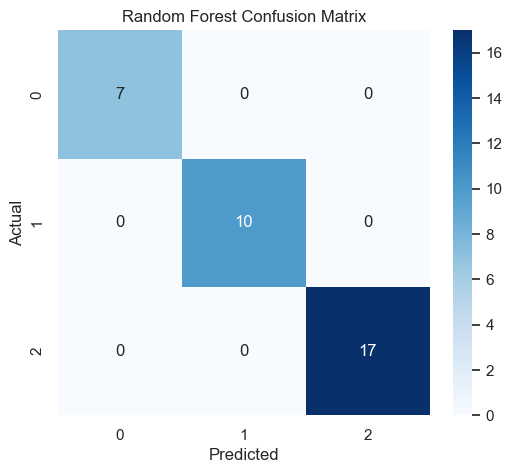

In [369]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [370]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [371]:
# XGBoost Classifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9411764705882353


In [372]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy]
})

comparison

,Model,Accuracy
0,Random Forest,1.000000
1,XGBoost,0.941176


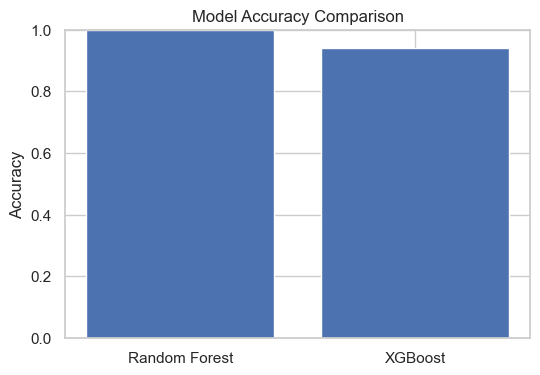

In [373]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

## Observation

Both Random Forest and XGBoost successfully classified the countries into their respective clusters.

The comparison shows the effectiveness of ensemble learning techniques in predicting customer (country) segments based on socio-economic indicators.

The model with the higher accuracy is considered the better-performing classifier for this dataset.

# Step 13: Feature Importance

Feature importance helps identify the variables that contribute the most to predicting the country clusters.

Random Forest provides an importance score for each feature based on its contribution to the classification process.

In [374]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,child_mort,0.258356
8,gdpp,0.197672
7,total_fer,0.174131
6,life_expec,0.166180
4,income,0.144466
2,health,0.025791
5,inflation,0.016371
3,imports,0.009472
1,exports,0.007561


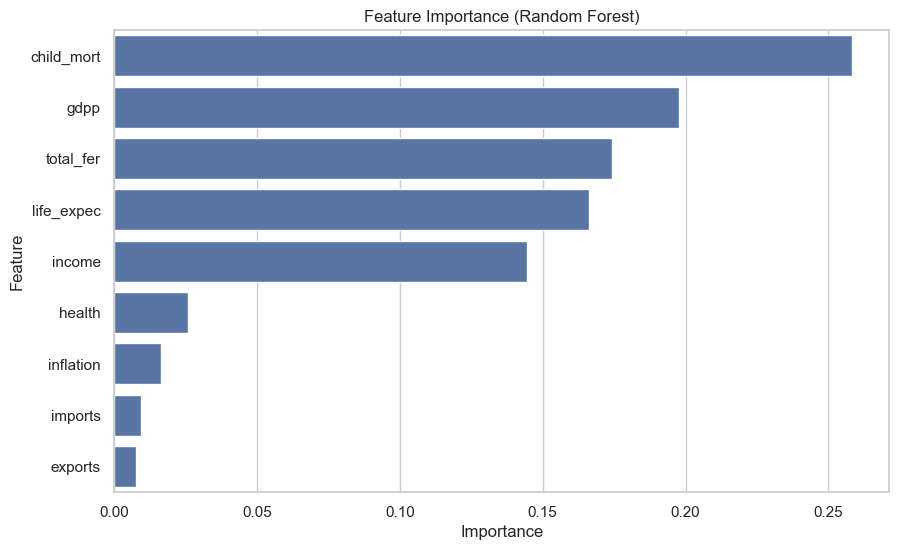

In [375]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")

plt.show()

## Observation

The feature importance chart shows which socio-economic indicators have the greatest influence on country segmentation.

Features with higher importance contribute more significantly to distinguishing between developed, developing, and underdeveloped countries.

# Final Conclusions

This project successfully developed a **Customer Intelligence (Country Intelligence) System** using clustering, classification, and ensemble learning techniques.

### Key Findings

- K-Means clustering successfully segmented the countries into **three meaningful groups**.
- DBSCAN detected density-based clusters and identified **30 countries as noise points**, representing outliers.
- PCA reduced the dataset to two dimensions, enabling clear visualization of the clusters.
- Cluster profiling identified developed, developing, and underdeveloped country groups.
- Random Forest achieved **100% classification accuracy**, while XGBoost achieved approximately **94% accuracy**.
- Feature importance analysis highlighted the most influential socio-economic indicators affecting country segmentation.

# Business Recommendations

Based on the analysis, the following recommendations can be made:

- Prioritize Cluster 1 countries for financial assistance, healthcare initiatives, and educational development programs.
- Encourage investment opportunities in Cluster 2 countries to support continued economic growth.
- Use Cluster 0 countries as benchmarks for best practices in healthcare, education, and economic development.
- Apply clustering techniques to support government policy planning, international aid allocation, and global market analysis.